# Notebook 1

## Data overview

Author: Morgan Lee

Purpose:
The goal of this notebook is to understand the NASA FD001 training dataset before performing any machine learning.

# Load libraries and dataset

In [21]:
import pandas as pd
train_df = pd.read_csv('../data/interim/train_FD001.csv')

# Initial inspection

In [22]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_measurement_1   20631 non-null  float64
 6   sensor_measurement_2   20631 non-null  float64
 7   sensor_measurement_3   20631 non-null  float64
 8   sensor_measurement_4   20631 non-null  float64
 9   sensor_measurement_5   20631 non-null  float64
 10  sensor_measurement_6   20631 non-null  float64
 11  sensor_measurement_7   20631 non-null  float64
 12  sensor_measurement_8   20631 non-null  float64
 13  sensor_measurement_9   20631 non-null  float64
 14  sensor_measurement_10  20631 non-null  float64
 15  sensor_measur

## Dataset information

Dataset dimensions: 20631 rows x 26 columns.

Column descriptions:
- (0) Engine identifier.
- (1) Engine cycle.
- (2-4) Operational settings.
- (5-25) Sensor measurements.

Memory usage: 4.1 MB


# Engine lifetime inspection

In [23]:
engine_lifetimes = (
    train_df
        .groupby("unit_number")["time_in_cycles"]
        .max()
)

In [24]:
engine_lifetimes.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64

## Observations
- The dataset contains 100 engine units, giving the model examples of many different engine life cycles instead of just one.
- There are 26 columns containing different measurements: time in cycles, operational settings, and sensor measurements.
- The time is measured in cycles rather than years/days/hours.
- An average engine lasts around 206 cycles while the best one lasted 362 cycles.
- Dataset does not yet include the RUL column.
- No missing values were found.
- The lifetime between each engine varies considerably. 

# Engine lifetime distribution

In this section we investigate how long engines typically operate before failure.

# Import libraries

In [25]:
import matplotlib.pyplot as plt
import os

In [26]:
engine_lifetimes.head()

unit_number
1    192
2    287
3    179
4    189
5    269
Name: time_in_cycles, dtype: int64

# Histogram

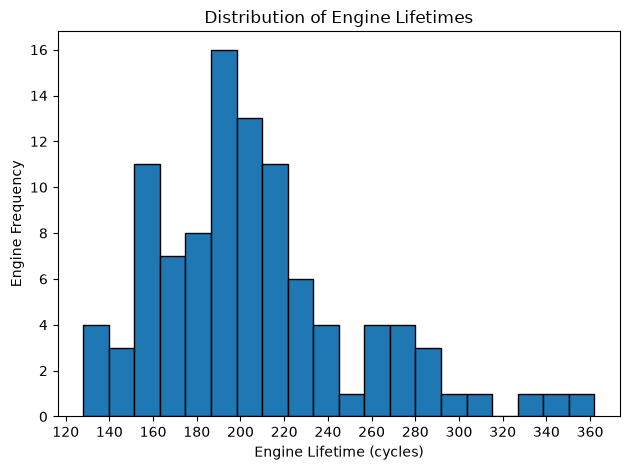

In [27]:
plt.hist(engine_lifetimes, bins=20, edgecolor='black')
plt.xticks(range(120, 380, 20))
plt.title('Distribution of Engine Lifetimes')
plt.xlabel('Engine Lifetime (cycles)')
plt.ylabel('Engine Frequency')
plt.tight_layout()

# Save the histogram to the reports/figures directory
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/engine_lifetime_distribution.png')

# Graph analysis

- Most of the engines fall between 160 and 240 life cycles.
- The peak is around 190 to 200 cycles, where the highest number of engines fail.
- There is a right skewed distribution, telling us that there are engines that last far longer that the majority. These engines last up to 330-360 life cycles.
- There aren't many engines failing before 150 life cycles, which suggests that catastrophic early failures are uncommon in this data set. 
- The data looks well distributed, this is good because machine learning models benefit from having examples across a range of lifetimes.

# Sensor Variability Analysis

In this section we investigate how much each sensor changes across the dataset.

In [28]:
sensor_columns = [col for col in train_df.columns if col.startswith('sensor')]
sensor_data = train_df[sensor_columns]
sensor_data.var().sort_values(ascending=False).head(10)

sensor_measurement_9     487.653568
sensor_measurement_14    363.900490
sensor_measurement_4      81.010886
sensor_measurement_3      37.590994
sensor_measurement_17      2.398667
sensor_measurement_7       0.783388
sensor_measurement_12      0.543985
sensor_measurement_2       0.250053
sensor_measurement_11      0.071336
sensor_measurement_20      0.032669
dtype: float64

## Sensor Variability Observations
- Sensor with the top variance: 
    - (1) Sensor 9
    - (2) Sensor 14
    - (3) Sensor 4
    - (4) Sensor 3
    - (5) Sensor 17
- Sensors with zero or near zero variance will be excluded from the dataset, since low variance in data does not tell us anything useful.

# Correlation Analysis

In this section we investigate relationships between sensor measurements.

Highly correlated sensors may contain similar information and could be candidates for feature selection later.

# Correlation Matrix Heatmap

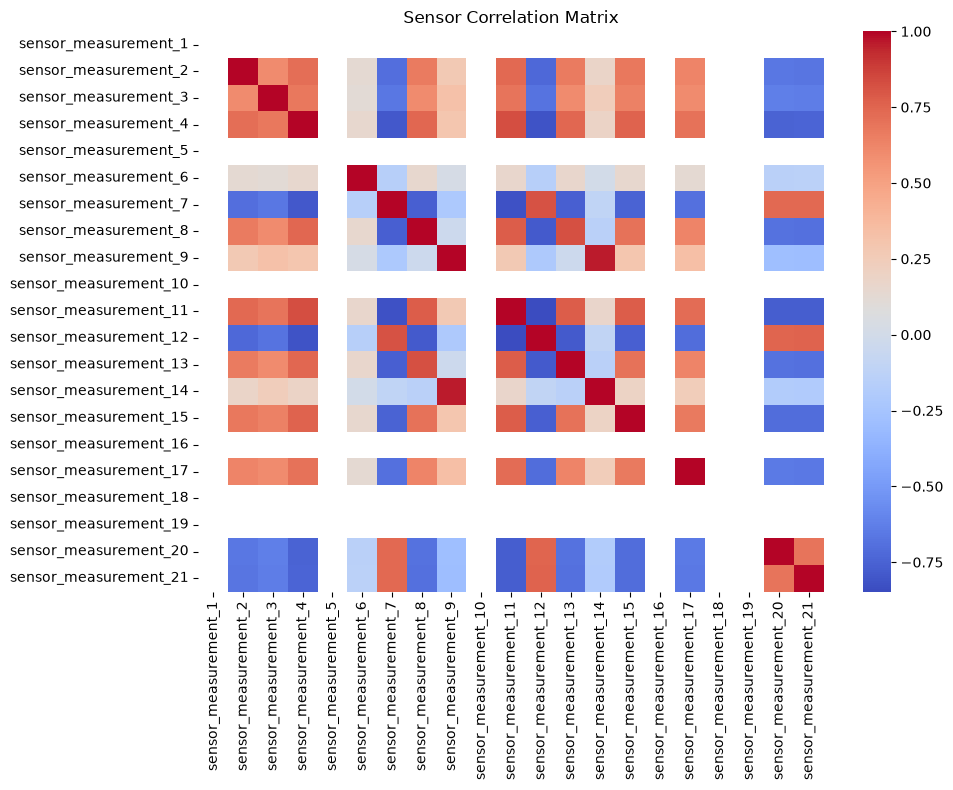

In [29]:
import jinja2
import seaborn as sns
correlation_matrix = sensor_data.corr(method='pearson')
correlation_matrix.style.background_gradient(cmap='coolwarm')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt='.2f')
plt.title('Sensor Correlation Matrix')
plt.tight_layout()

# Save the heatmap to the reports/figures directory
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/correlation_matrix.png')

# Correlation Observations

- Sensor 9 and Sensor 14 have a perfect positive correlation, indicating they contain essentially the same information. As one increases, the other increases proportionally.
- Keeping 2 sensors track the same engine might be unecessary since they may be measuring the same physical process using different units, or they may be two sensors installed on closely related components that always behave similarly.
- However, keeping 2 sensors on a single engine can also give you a backup engine in case one fails.